# PQC Benchmark Analysis
This notebook provides a graphical analysis of benchmarking results for two web servers using different key exchange mechanisms: X25519 and X25519MLKEM768.

## Imports and environment setup
The following libraries are imported to support benchmark analysis and visualization. They are used for tabular data processing, numerical computation, file discovery, path handling, and chart generation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path
import glob
import math

## Configuration and data preparation
This section defines plotting settings, loads benchmark data, normalizes selected fields, and prepares shared variables used throughout the analysis.

In [3]:
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

CLASSIC_COLOR = '#2166ac'
HYBRID_COLOR  = '#d6604d'
ALPHA = 0.85

FIGURES_DIR = Path('results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

files = sorted(glob.glob('input/curl_benchmark/benchmark_*.csv'))
assert files, "No CSV files found in results/raw/"
print(f'Found {len(files)} CSV files')

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df['endpoint'] = df['endpoint'].apply(
    lambda x: x.split('/', 1)[-1] if ':' in x else x
)

VARIANTS = df['variant'].unique().tolist()
assert 'classic' in VARIANTS and 'hybrid' in VARIANTS, \
    f"Expected 'classic' and 'hybrid' variants, got: {VARIANTS}"

ENDPOINT_ORDER = (
    df.groupby('endpoint')['size_bytes']
    .median()
    .sort_values()
    .index
    .tolist()
)

def make_label(ep, median_bytes):
    if median_bytes < 1024:
        return f'direct\n({int(median_bytes)} B)'
    elif median_bytes < 1024 * 1024:
        return f'{median_bytes/1024:.0f} KB'
    else:
        return f'{median_bytes/1024/1024:.0f} MB'

median_sizes = df.groupby('endpoint')['size_bytes'].median()
ENDPOINT_LABELS = {
    ep: make_label(ep, median_sizes[ep])
    for ep in ENDPOINT_ORDER
}

x = np.arange(len(ENDPOINT_ORDER))
width = 0.35

print(f'Variants:  {VARIANTS}')
print(f'Endpoints: {ENDPOINT_ORDER}')
print(f'Labels:    {ENDPOINT_LABELS}')
print(f'Total rows: {len(df)}')

Found 7 CSV files
Variants:  ['classic', 'hybrid']
Endpoints: ['api/direct', 'api/payload/1kb', 'api/payload/100kb', 'api/payload/1mb']
Labels:    {'api/direct': 'direct\n(2 B)', 'api/payload/1kb': '1 KB', 'api/payload/100kb': '100 KB', 'api/payload/1mb': '1 MB'}
Total rows: 11200



Per-Layer Latency Decomposition (ms)
Layer            Classic mean  Classic SD  Hybrid mean  Hybrid SD  Diff ms  Diff %
TCP Handshake           1.428       1.240        1.150      0.713   -0.278   -19.5%
TCP→TLS Delay           3.537       0.456        3.903      0.339   +0.365   +10.3%
TLS Handshake           4.726       0.595        4.925      0.604   +0.199    +4.2%
TLS→App Delay           0.160       0.044        0.148      0.039   -0.011    -7.0%
App Response            0.759       0.251        0.960      0.889   +0.201   +26.4%


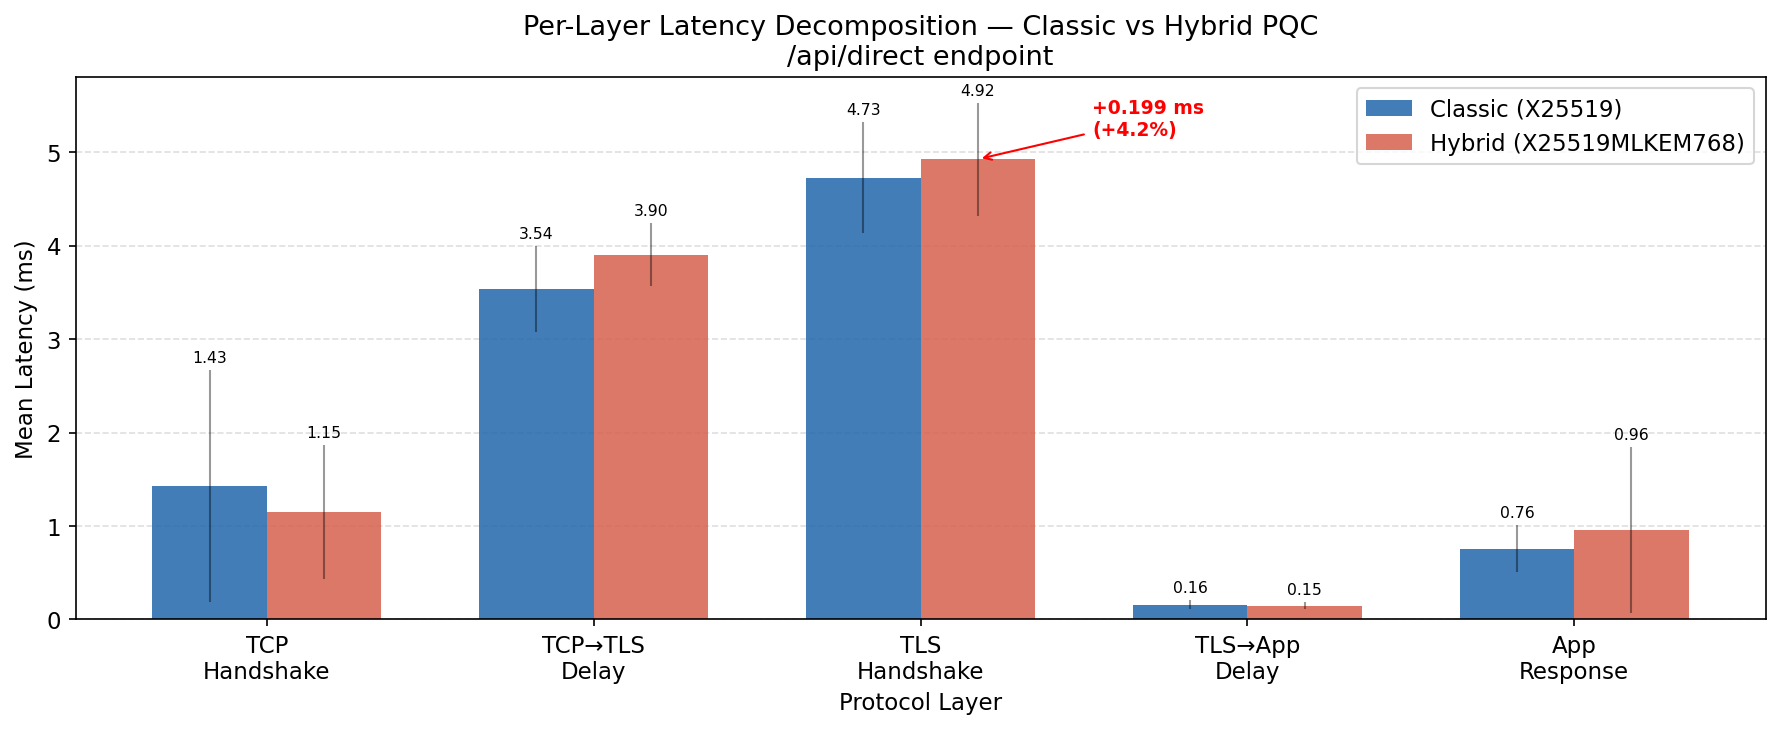

Saved fig8


In [ ]:
# Wireshark — Full per-layer decomposition

# CSV input meanings:
# tcp_hs  = TCP Handshake  = ACK - SYN
# tcp_tls = TCP→TLS Delay  = ClientHello - ACK
# tls_hs  = TLS Handshake  = ClientFinished - ClientHello
# tls_app = TLS→App Delay  = GET - ClientFinished
# app_resp= App Response   = HTTP 200 - GET
# ================================

ws_df_raw = pd.read_csv('input/layered_analysis/results.csv')

layers_raw = {'classic': [], 'hybrid': []}
for _, row in ws_df_raw.iterrows():
    layers_raw[row['variant']].append({
        'tcp_hs':   row['tcp_hs'],
        'tcp_tls':  row['tcp_tls'],
        'tls_hs':   row['tls_hs'],
        'tls_app':  row['tls_app'],
        'app_resp': row['app_resp'],
    })

layer_keys   = ['tcp_hs', 'tcp_tls', 'tls_hs', 'tls_app', 'app_resp']
layer_labels = ['TCP\nHandshake', 'TCP→TLS\nDelay', 'TLS\nHandshake',
                'TLS→App\nDelay', 'App\nResponse']

import statistics as _st
means, sds = {}, {}
for v in ['classic', 'hybrid']:
    means[v] = {l: _st.mean(d[l] for d in layers_raw[v]) for l in layer_keys}
    sds[v]   = {l: _st.stdev(d[l] for d in layers_raw[v]) for l in layer_keys}

print('\nPer-Layer Latency Decomposition (ms)')
print(f"{'Layer':15} {'Classic mean':>13} {'Classic SD':>11} {'Hybrid mean':>12} {'Hybrid SD':>10} {'Diff ms':>8} {'Diff %':>7}")
print('=' * 85)
for l, lbl in zip(layer_keys, layer_labels):
    cm, cs = means['classic'][l], sds['classic'][l]
    hm, hs = means['hybrid'][l],  sds['hybrid'][l]
    diff_ms  = hm - cm
    diff_pct = diff_ms / cm * 100
    print(f"{lbl.replace(chr(10),' '):15} {cm:>13.3f} {cs:>11.3f} {hm:>12.3f} {hs:>10.3f} {diff_ms:>+8.3f} {diff_pct:>+7.1f}%")

fig, ax = plt.subplots(figsize=(12, 5))
xl = np.arange(len(layer_keys))
w  = 0.35

for i, (variant, color, label) in enumerate([
    ('classic', CLASSIC_COLOR, 'Classic (X25519)'),
    ('hybrid',  HYBRID_COLOR,  'Hybrid (X25519MLKEM768)'),
]):
    vals = [means[variant][l] for l in layer_keys]
    errs = [sds[variant][l]   for l in layer_keys]
    offset = (i - 0.5) * w
    bars = ax.bar(xl + offset, vals, w,
                  color=color, alpha=ALPHA, label=label,
                  yerr=errs, capsize=0,
                  error_kw=dict(elinewidth=1, ecolor='black', alpha=0.4))
    for bar, val, err in zip(bars, vals, errs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + err + 0.05,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)

tls_idx = 2
cm_tls = means['classic']['tls_hs']
hm_tls = means['hybrid']['tls_hs']
ax.annotate(
    f"+{hm_tls - cm_tls:.3f} ms\n({(hm_tls - cm_tls) / cm_tls * 100:+.1f}%)",
    xy=(xl[tls_idx] + w/2, hm_tls),
    xytext=(xl[tls_idx] + w/2 + 0.35, hm_tls + 0.25),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=9, color='red', fontweight='bold'
)

ax.set_xlabel('Protocol Layer')
ax.set_ylabel('Mean Latency (ms)')
ax.set_title('Per-Layer Latency Decomposition — Classic vs Hybrid PQC\n'
             '/api/direct endpoint')
ax.set_xticks(xl)
ax.set_xticklabels(layer_labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig8_wireshark_layers.pdf')
plt.show()
print('Saved fig8')
